# 📊 Monte Carlo Risk Analysis – Hindustan Unilever

This project uses Monte Carlo Simulation to forecast possible future stock prices and analyze risk.

### Objectives:
- Simulate future price paths
- Estimate expected return
- Calculate probability of loss
- Evaluate Value at Risk (VaR)

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
#Fetching Data
TICKER = "HINDUNILVR.NS"
PERIOD = "3y"

data = yf.download(TICKER, period=PERIOD)

if 'Adj Close' in data.columns:
    prices = data['Adj Close'].dropna()
else:
    prices = data['Close'].dropna()

prices.tail()

C:\Users\iamfa\AppData\Local\Temp\ipykernel_28772\3196876976.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, period=PERIOD)
[*********************100%***********************]  1 of 1 completed


Ticker,HINDUNILVR.NS
Date,
2026-03-19,2077.300049
2026-03-20,2082.699951
2026-03-23,2052.199951
2026-03-24,2085.000000
2026-03-25,2134.800049


In [ ]:
# Returns & Volatility
log_returns = np.log(prices / prices.shift(1)).dropna()

mu = log_returns.mean()
sigma = log_returns.std()

print("Drift (mu):", mu)
print("Volatility (sigma):", sigma)

Drift (mu): Ticker
HINDUNILVR.NS   -0.000139
dtype: float64
Volatility (sigma): Ticker
HINDUNILVR.NS    0.01179
dtype: float64


In [ ]:
# Monte Carlo Function
def monte_carlo(S0, mu, sigma, days=252, simulations=300):
    dt = 1
    paths = np.zeros((days, simulations))

    for sim in range(simulations):
        prices = np.zeros(days)
        prices[0] = S0

        for t in range(1, days):
            drift = (mu - 0.5 * sigma**2)
            shock = sigma * np.random.normal()
            prices[t] = prices[t-1] * np.exp(drift + shock)

        paths[:, sim] = prices

    return paths

In [ ]:
# Run Simulation
S0 = prices.iloc[-1].item()

paths = monte_carlo(S0, mu, sigma)

C:\Users\iamfa\AppData\Local\Temp\ipykernel_28772\3380825953.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices[t] = prices[t-1] * np.exp(drift + shock)


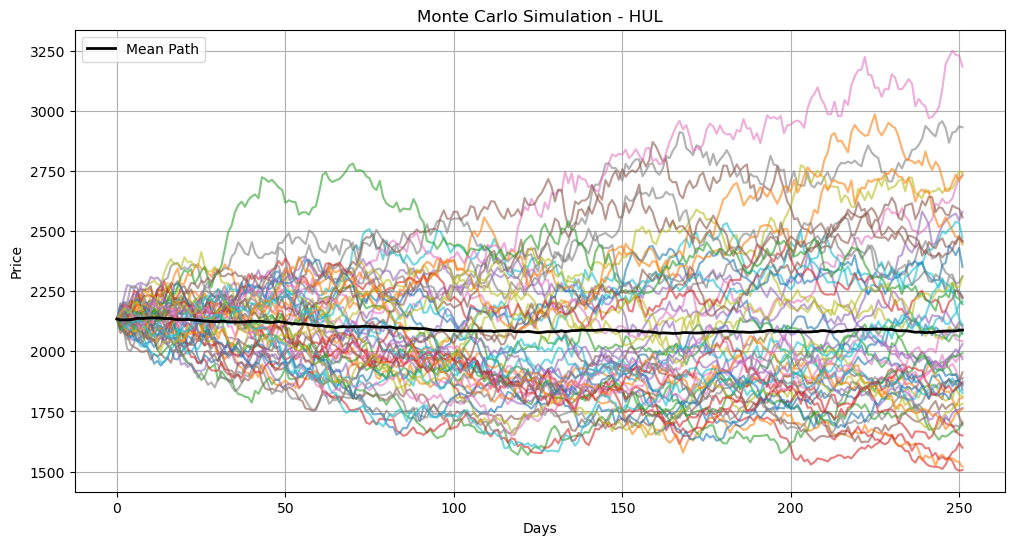

In [ ]:
#Plot Simulation
plt.figure(figsize=(12,6))

# Plotting simulation paths
for i in range(50):
    plt.plot(paths[:, i], alpha=0.6)

# Plot mean path ONCE
plt.plot(paths.mean(axis=1), color='black', linewidth=2, label='Mean Path')

plt.legend()
plt.title("Monte Carlo Simulation - HUL")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid()
plt.show()

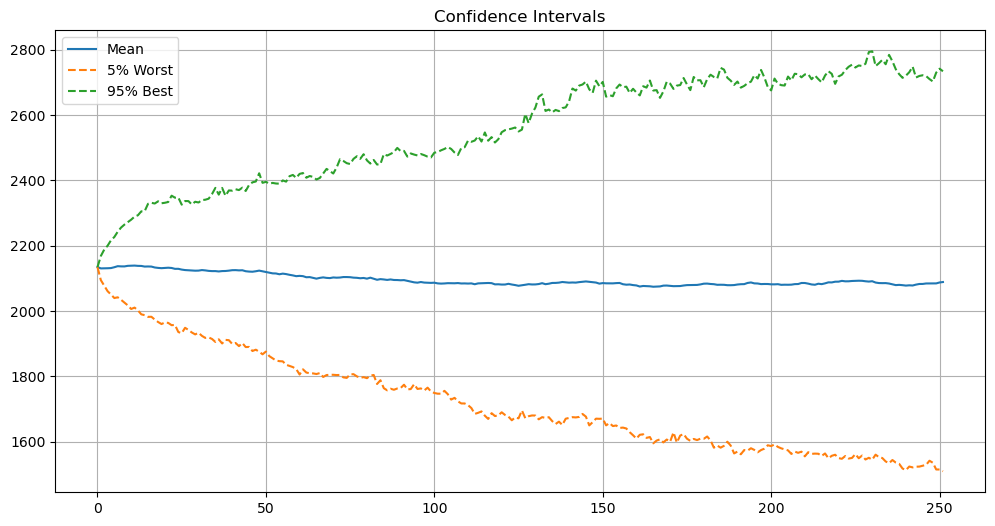

In [ ]:
#Confidence Intervals
mean_path = paths.mean(axis=1)
p5 = np.percentile(paths, 5, axis=1)
p95 = np.percentile(paths, 95, axis=1)

plt.figure(figsize=(12,6))
plt.plot(mean_path, label="Mean")
plt.plot(p5, linestyle="--", label="5% Worst")
plt.plot(p95, linestyle="--", label="95% Best")

plt.legend()
plt.title("Confidence Intervals")
plt.grid()
plt.show()

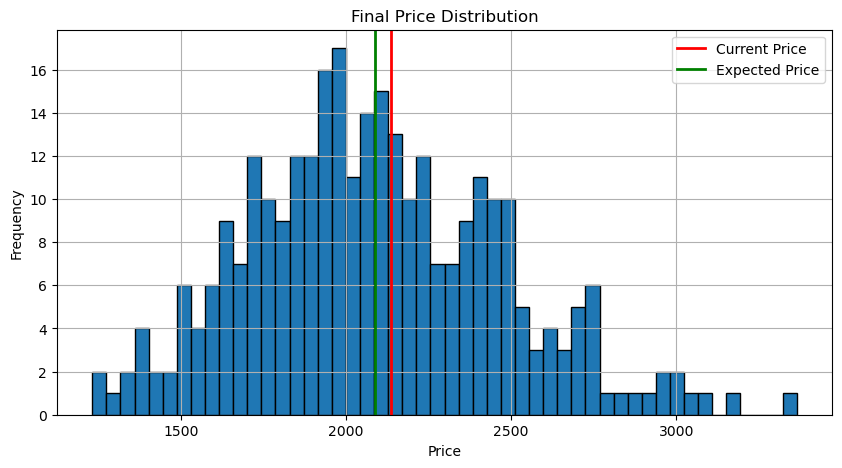

In [ ]:
# Distribution
plt.figure(figsize=(10,5))

plt.hist(final_prices, bins=50, edgecolor='black')

plt.axvline(S0, color='red', linewidth=2, label='Current Price')
plt.axvline(np.mean(final_prices), color='green', linewidth=2, label='Expected Price')

plt.title("Final Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid()

plt.show()

In [ ]:
#Metrics
final_prices = np.array(final_prices)

expected_price = np.mean(final_prices)
expected_return = (expected_price - S0) / S0
prob_loss = np.mean(final_prices < S0)
VaR_95 = np.percentile(final_prices, 5)

print(f"Initial Price: {S0:.2f}")
print(f"Expected Price: {expected_price:.2f}")
print(f"Expected Return: {expected_return*100:.2f}%")
print(f"Probability of Loss: {prob_loss*100:.2f}%")
print(f"VaR (95%): {VaR_95:.2f}")

Initial Price: 2134.80
Expected Price: 2088.95
Expected Return: -2.15%
Probability of Loss: 58.33%
VaR (95%): 1509.33


## 📊 Interpretation

- The expected return is slightly negative, indicating weak growth potential.
- The probability of loss is above 50%, suggesting higher downside risk.
- The Value at Risk (VaR) indicates significant potential loss in worst-case scenarios.

### 📌 Conclusion:
Hindustan Unilever shows moderate volatility with a higher likelihood of loss, making it a relatively risky short-term investment under current conditions.